# Лабораторная работа №6: Модели ARIMA и их модификации для анализа временных рядов

In [2]:
# Установка необходимых библиотек
!pip install pmdarima statsmodels scikit-learn

# Импорт модулей
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
import pmdarima as pm
from scipy.stats import boxcox
from scipy.special import inv_boxcox

# Загрузка файла (если используется интерактивный виджет)
from google.colab import files
uploaded = files.upload()

# Чтение исходного набора данных
df = pd.read_csv('data.csv', encoding='ISO-8859-1') # Добавлен encoding во избежание ошибок чтения

# Предобработка временной метки
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], errors='coerce')
df.dropna(subset=['InvoiceDate'], inplace=True)
df.sort_values('InvoiceDate', inplace=True)

# Извлечение только даты (без времени) для корректной посуточной агрегации
df['date'] = df['InvoiceDate'].dt.date
df['date'] = pd.to_datetime(df['date'])

# Фильтрация возможных аномалий возвратов (отрицательные объемы)
df = df[df['Quantity'] > 0]

# Формирование регулярного временного ряда (посуточный суммарный объем продаж)
total = df.groupby('date')['Quantity'].sum().reset_index()
total.columns = ['date', 'total_quantity']
total.set_index('date', inplace=True)

# Приведение к фиксированной ежедневной частоте (заполнение пропущенных дней нулями)
total = total.asfreq('D', fill_value=0)

print(f"Размер сформированного временного ряда: {len(total)} наблюдений")
print(total.head())

Saving data.csv to data.csv
Размер сформированного временного ряда: 374 наблюдений
            total_quantity
date                      
2010-12-01           27007
2010-12-02           31348
2010-12-03           16471
2010-12-04               0
2010-12-05           16451


# 1.1 Визуальный анализ временного ряда розничных продаж
Для первичного определения структуры ряда построим график ежедневного объема продаж. Чтобы снизить уровень высокочастотного шума и выявить скрытые закономерности (недельную сезонность и макротенденции), дополнительно отобразим 7-дневное скользящее среднее.

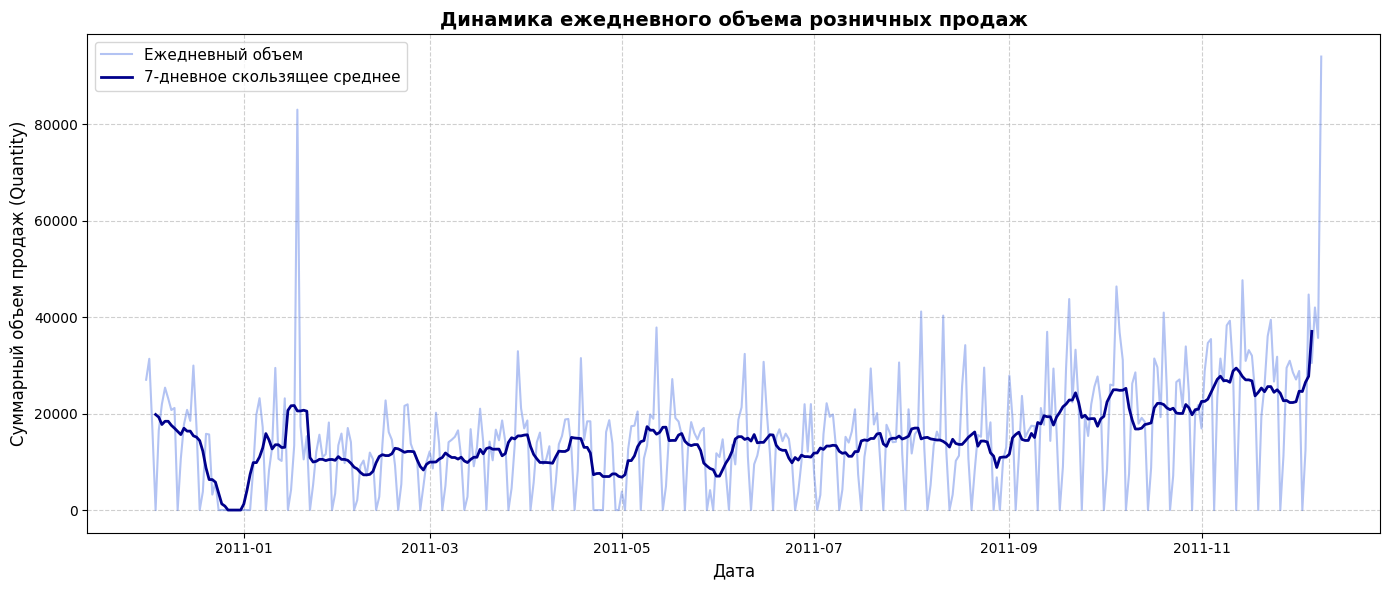

In [5]:
# 1.1 График временного ряда розничных продаж
plt.figure(figsize=(14, 6))

# График исходного ряда (ежедневный объем)
plt.plot(total.index, total['total_quantity'], color='royalblue', alpha=0.4, label='Ежедневный объем')

# Сглаженный график (7-дневное скользящее среднее для выделения недельной сезонности)
plt.plot(total.index, total['total_quantity'].rolling(window=7, center=True).mean(),
         color='darkblue', linewidth=2, label='7-дневное скользящее среднее')

plt.title('Динамика ежедневного объема розничных продаж', fontsize=14, fontweight='bold')
plt.xlabel('Дата', fontsize=12)
plt.ylabel('Суммарный объем продаж (Quantity)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='upper left', fontsize=11)

plt.tight_layout()
plt.show()

# 1.2 Проверка стационарности (тест Дики-Фуллера) и стабилизация ряда
Для корректного применения моделей семейства ARIMA временной ряд должен быть стационарным (его математическое ожидание и дисперсия должны быть постоянными во времени). На данном этапе реализуется статистический тест Дики-Фуллера (ADF) для проверки исходного ряда на стационарность.

В случае обнаружения нестационарности (высокий $p-value > 0.05$) применяется логарифмирование для стабилизации дисперсии и взятие первой разности (дифференцирование) для устранения тренда. Из-за наличия нулевых объемов продаж в некоторые дни вместо классического логарифма $\ln(x)$ применяется преобразование $\ln(x + 1)$, чтобы избежать неопределенности $\ln(0)$.

<>:35: SyntaxWarning: invalid escape sequence '\D'
<>:35: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_2976/1305258329.py:35: SyntaxWarning: invalid escape sequence '\D'
  plt.ylabel('Разность $\Delta \ln(Quantity + 1)$', fontsize=12)


Результаты ADF теста для исходного ряда продаж:
ADF статистика: -0.8731
p-value: 0.7967
Критические значения:
   1%: -3.4486
   5%: -2.8696
   10%: -2.5711
Вывод: Ряд нестационарен (не удается отвергнуть нулевую гипотезу H0)

Результаты ADF теста для первой разности логарифмированного ряда:
ADF статистика: -6.2698
p-value: 0.0000
Критические значения:
   1%: -3.4489
   5%: -2.8697
   10%: -2.5711
Вывод: Ряд стационарен (отвергаем нулевую гипотезу H0)



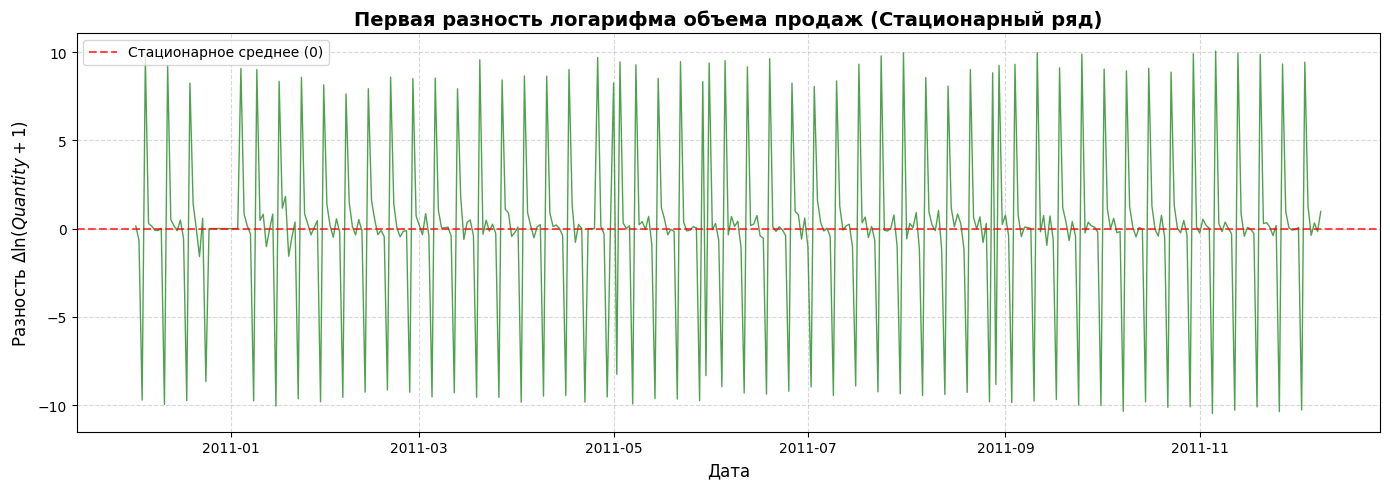

In [7]:
# Функция для проведения расширенного теста Дики-Фуллера (ADF)
def adf_test(series, title=''):
    result = adfuller(series, autolag='AIC')
    print(f'Результаты ADF теста для {title}:')
    print(f'ADF статистика: {result[0]:.4f}')
    print(f'p-value: {result[1]:.4f}')
    print('Критические значения:')
    for key, value in result[4].items():
        print(f'   {key}: {value:.4f}')
    if result[1] <= 0.05:
        print("Вывод: Ряд стационарен (отвергаем нулевую гипотезу H0)\n")
    else:
        print("Вывод: Ряд нестационарен (не удается отвергнуть нулевую гипотезу H0)\n")

# Проверка исходного ряда объемов розничных продаж
adf_test(total['total_quantity'], 'исходного ряда продаж')

# 1.3 Приведение к стационарности
# Используем np.log1p(x) = log(x + 1), так как в ряду продаж присутствуют нулевые дни
total['log_quantity'] = np.log1p(total['total_quantity'])

# Взятие первой последовательной разности для удаления тренда
total['diff_log'] = total['log_quantity'].diff()

# Повторная проверка стационарности полученного разностного ряда (исключая первое NaN значение)
adf_test(total['diff_log'].dropna(), 'первой разности логарифмированного ряда')

# 1.4 Визуализация стационарного временного ряда
plt.figure(figsize=(14, 5))
plt.plot(total.index, total['diff_log'], color='forestgreen', alpha=0.8, linewidth=1)

plt.axhline(0, color='red', linestyle='--', alpha=0.7, label='Стационарное среднее (0)')
plt.title('Первая разность логарифма объема продаж (Стационарный ряд)', fontsize=14, fontweight='bold')
plt.xlabel('Дата', fontsize=12)
plt.ylabel('Разность $\Delta \ln(Quantity + 1)$', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='upper left')

plt.tight_layout()
plt.show()

# 2. Базовая ARIMA-модель. Ручной подбор параметров $(p, d, q)

Для идентификации порядка базовой модели $\text{ARIMA}(p, d, q)$ производится визуальный анализ автокорреляционной (ACF) и частично автокорреляционной (PACF) функций стационарного ряда разностей.

Анализ графиков позволяет вручную определить начальные значения параметров:
$p$ (порядок авторегрессии $\text{AR}$) — определяется по числу значимых (выходящих за пределы доверительного интервала) лагов на графике PACF.

$d$ (порядок интегрирования) — в данном случае равен $1$, так как стационарность была достигнута после взятия первой разности.

$q$ (порядок скользящего среднего $\text{MA}$) — определяется по числу значимых лагов на графике ACF.

Поскольку розничные продажи часто обладают сильной недельной цикличностью, лаги, кратные 7 (7, 14, 21), могут отражать регулярную сезонность. При ручном подборе для базовой несезонной модели ARIMA мы фокусируемся на первых (краткосрочных) лагах.

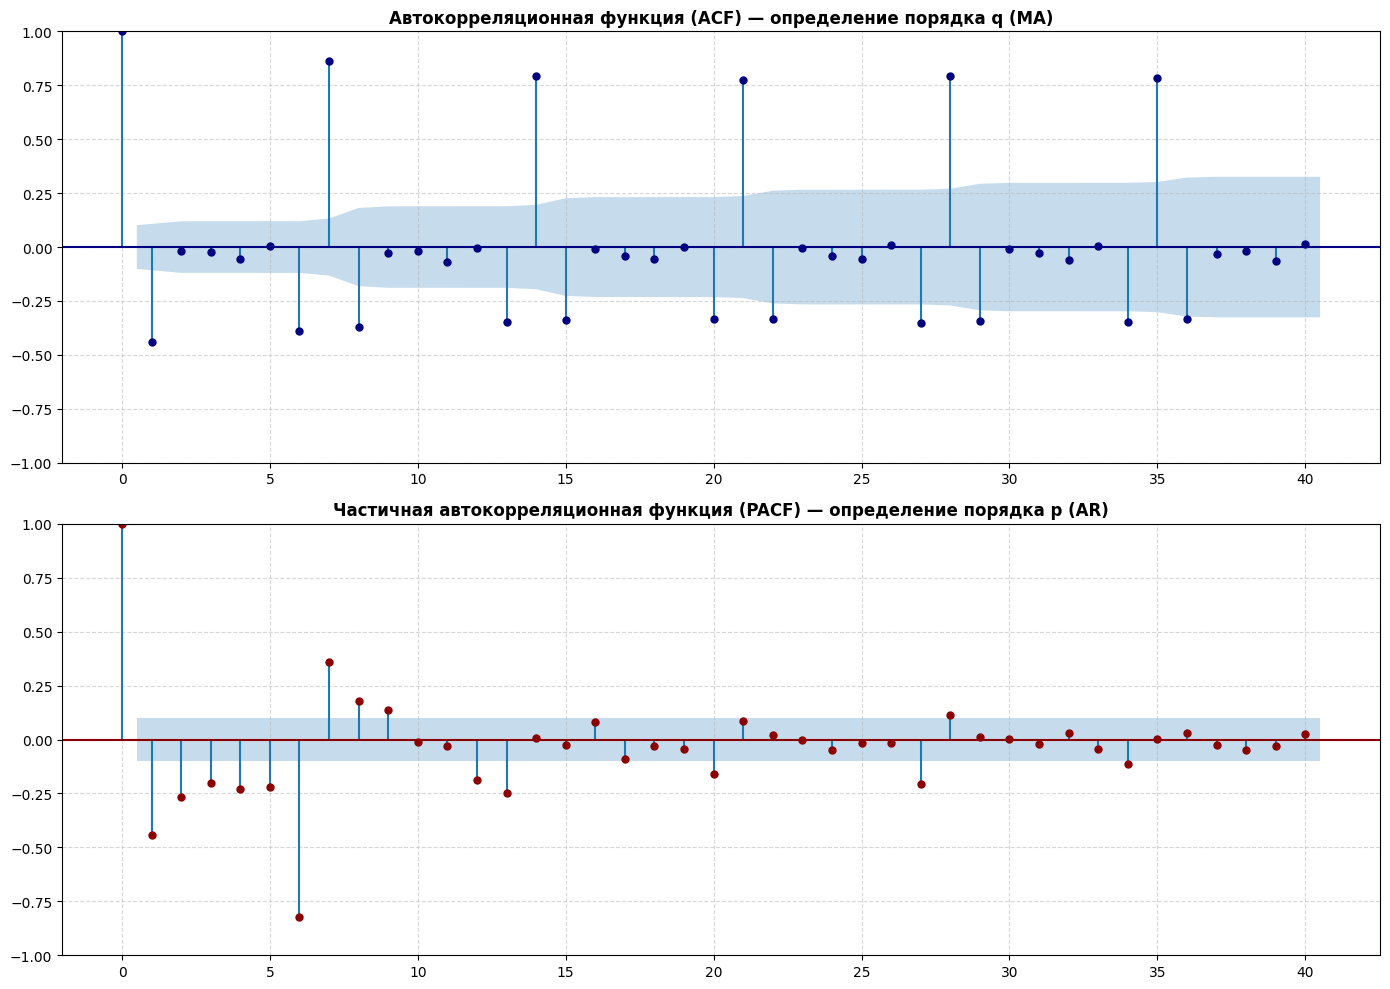

In [8]:
# 2.1 Построение графиков ACF и PACF для стационарного ряда разностей
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

# График автокорреляционной функции (ACF) для определения параметра q
plot_acf(total['diff_log'].dropna(), ax=ax1, lags=40, alpha=0.05, color='navy')
ax1.set_title('Автокорреляционная функция (ACF) — определение порядка q (MA)', fontsize=12, fontweight='bold')
ax1.grid(True, linestyle='--', alpha=0.5)

# График частичной автокорреляционной функции (PACF) для определения параметра p
plot_pacf(total['diff_log'].dropna(), ax=ax2, lags=40, alpha=0.05, color='darkred', method='ywm')
ax2.set_title('Частичная автокорреляционная функция (PACF) — определение порядка p (AR)', fontsize=12, fontweight='bold')
ax2.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# 2.2 Разделение выборки на обучающую и тестовую, обучение модели ARIMA и оценка прогноза

Для корректной оценки прогностической силы модели временной ряд разбивается на два интервала: обучающий (train) и тестовый (test). Поскольку розничные данные имеют посуточную дискретизацию (в отличие от исходного ежемесячного ряда энергетики), в качестве тестовой выборки целесообразно выделить последние 30 дней (примерно 1 месяц), чтобы оценить краткосрочный прогноз.

На данном этапе инициализируется и обучается базовая модель $\text{ARIMA}(p, d, q)$ с параметрами, выбранными на основе анализа графиков ACF/PACF. Обучение производится на логарифмированном ряду log_quantity.

                               SARIMAX Results                                
Dep. Variable:           log_quantity   No. Observations:                  344
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -944.844
Date:                Tue, 19 May 2026   AIC                           1895.689
Time:                        18:49:44   BIC                           1907.202
Sample:                    12-01-2010   HQIC                          1900.275
                         - 11-09-2011                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1010      0.062      1.619      0.105      -0.021       0.223
ma.L1         -0.9873      0.023    -43.319      0.000      -1.032      -0.943
sigma2        14.3142      1.872      7.646      0.0

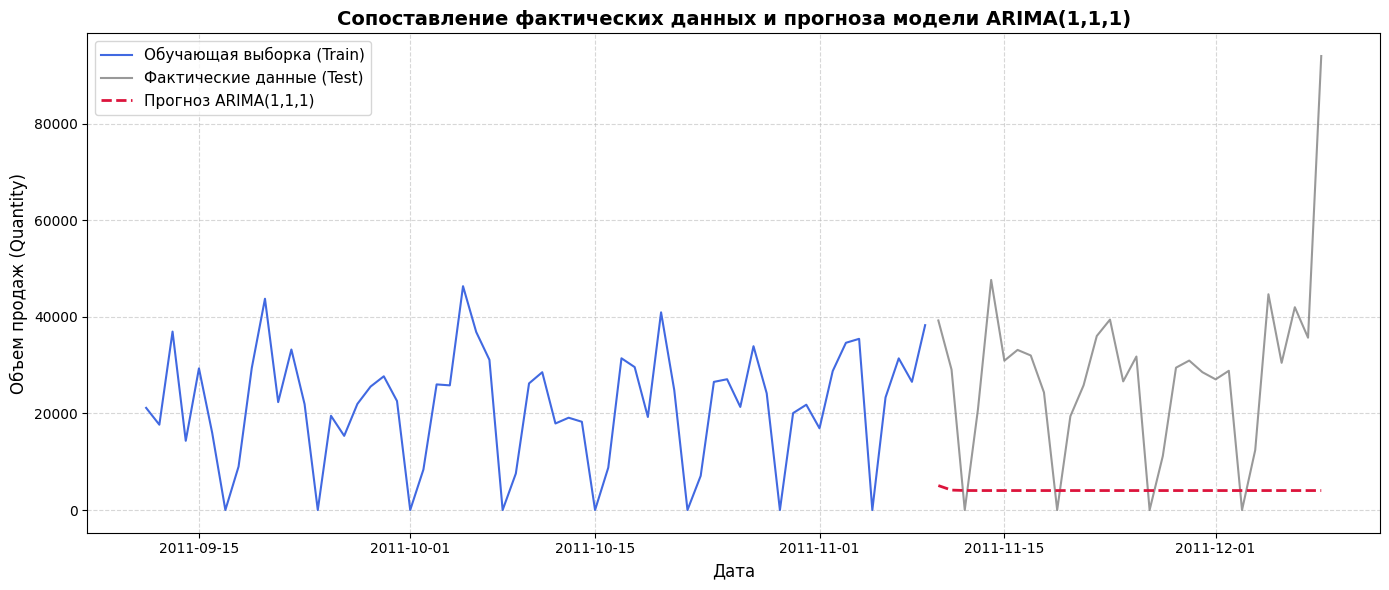

In [9]:
# Определение горизонта прогнозирования (30 дней для посуточного ряда розницы)
horizon = 30

# Разделение временного ряда (используем логарифмированную переменную)
train = total.iloc[:-horizon]
test = total.iloc[-horizon:]

# Инициализация и обучение базовой модели ARIMA
# Параметры (1, 1, 1) взяты в качестве базового примера; d=1, так как бралась первая разность
p, d, q = 1, 1, 1
model_arima = ARIMA(train['log_quantity'], order=(p, d, q))
model_arima_fit = model_arima.fit()

# Вывод краткого статистического отчета по обученной модели
print(model_arima_fit.summary())

# Генерация прогноза на тестовый интервал в логарифмической шкале
forecast_log = model_arima_fit.forecast(steps=horizon)

# Обратное преобразование прогноза и тестовых данных к исходной шкале объемов продаж
forecast_arima = np.expm1(forecast_log)
test_actual = np.expm1(test['log_quantity'])
train_actual = np.expm1(train['log_quantity'])

# Расчет академических метрик качества прогноза
rmse_arima = np.sqrt(mean_squared_error(test_actual, forecast_arima))
mape_arima = mean_absolute_percentage_error(test_actual, forecast_arima)

print("\n" + "="*50)
print(f'МЕТРИКИ КАЧЕСТВА НА ТЕСТОВОМ ИНТЕРВАЛЕ (исходная шкала):')
print(f'RMSE (ARIMA): {rmse_arima:.2f}')
print(f'MAPE (ARIMA): {mape_arima:.4f} ({mape_arima * 100:.2f}%)')
print("="*50)

# Визуализация результатов прогнозирования
plt.figure(figsize=(14, 6))

# Отображаем только часть обучающей выборки (например, последние 60 дней) для наглядности графика
plt.plot(train_actual.index[-60:], train_actual.iloc[-60:], label='Обучающая выборка (Train)', color='royalblue')
plt.plot(test_actual.index, test_actual, label='Фактические данные (Test)', color='gray', alpha=0.8)
plt.plot(test_actual.index, forecast_arima, label=f'Прогноз ARIMA({p},{d},{q})', color='crimson', linewidth=2, linestyle='--')

plt.title(f'Сопоставление фактических данных и прогноза модели ARIMA({p},{d},{q})', fontsize=14, fontweight='bold')
plt.xlabel('Дата', fontsize=12)
plt.ylabel('Объем продаж (Quantity)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='upper left', fontsize=11)

plt.tight_layout()
plt.show()

# 3. Диагностика модели. Анализ остатков ARIMA

После обучения базовой модели необходимо выполнить проверку адекватности её остатков (ошибок прогноза). Согласно статистической теории, если модель уловила все системные закономерности (тренд, авторегрессионные зависимости), то её остатки должны представлять собой «белый шум» — некоррелированную последовательность случайных величин с нулевым математическим ожиданием и постоянной дисперсией.

На данном этапе выполняются:

Построение графика динамики остатков во времени для визуального контроля постоянства дисперсии и отсутствия явных трендовых смещений.

Построение автокорреляционной функции (ACF) остатков для проверки отсутствия значимых взаимосвязей между ошибками на различных лагах.

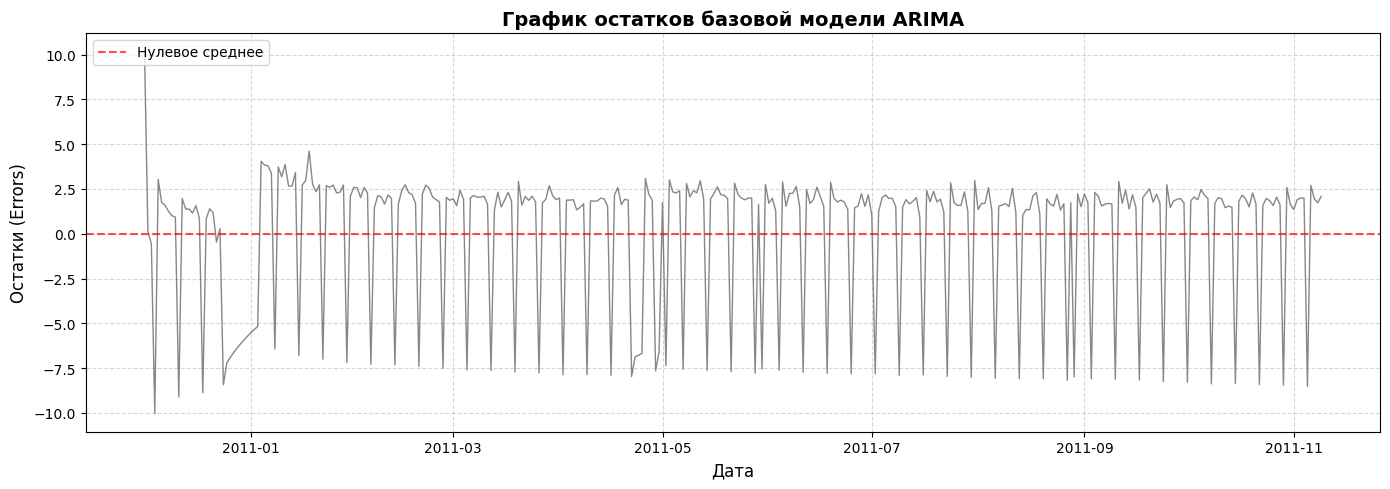

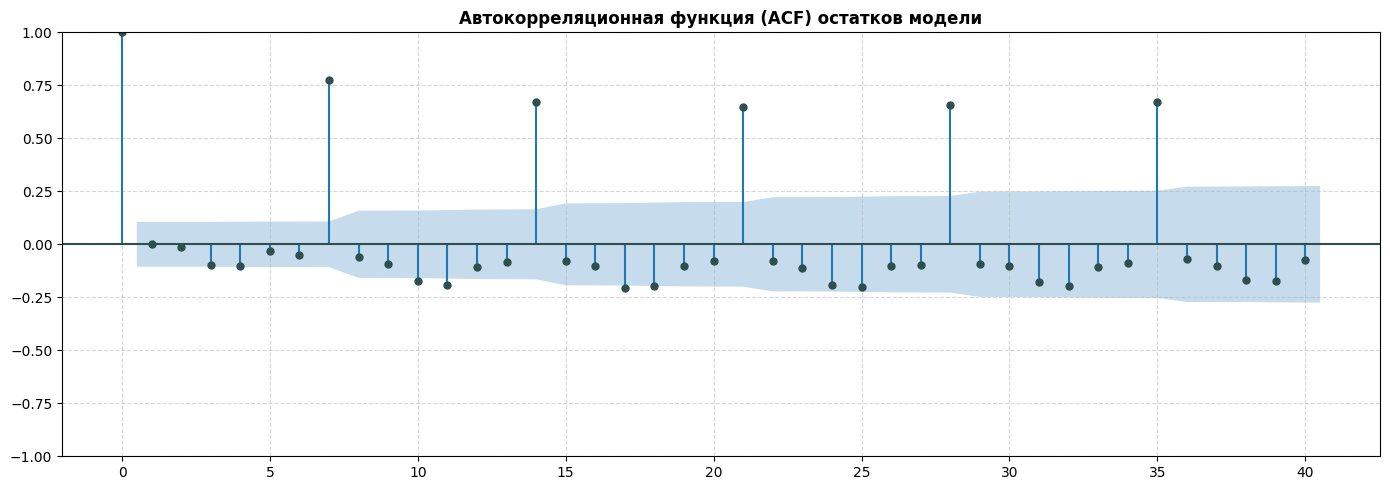

In [10]:
# 3.1 Извлечение остатков обученной модели ARIMA
residuals = model_arima_fit.resid

# Визуализация динамики остатков во времени
plt.figure(figsize=(14, 5))
plt.plot(residuals, color='dimgray', alpha=0.8, linewidth=1)

plt.axhline(0, color='red', linestyle='--', alpha=0.7, label='Нулевое среднее')
plt.title('График остатков базовой модели ARIMA', fontsize=14, fontweight='bold')
plt.xlabel('Дата', fontsize=12)
plt.ylabel('Остатки (Errors)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='upper left')

plt.tight_layout()
plt.show()

# 3.2 Построение автокорреляционной функции (ACF) для остатков
plt.figure(figsize=(14, 5))
ax = plt.gca()

# Строим ACF остатков для оценки наличия неучтенной автокорреляции
plot_acf(residuals, ax=ax, lags=40, alpha=0.05, color='darkslategrey')
ax.set_title('Автокорреляционная функция (ACF) остатков модели', fontsize=12, fontweight='bold')
ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# 3.4 Статистический тест Льюнга-Бокса для остатков

Для строгого подтверждения того, что остатки базовой модели представляют собой «белый шум», одного визуального анализа графиков недостаточно. Необходимо выполнить формальный статистический тест Льюнга-Бокса (Ljung-Box test). Этот тест проверяет гипотезу $H_0$ об отсутствии автокорреляции в остатках до указанного лага включительно. Если полученные значения $p-value > 0.05$, то гипотеза об отсутствии автокорреляции не отвергается, что свидетельствует об адекватности модели.

In [11]:
# Выполнение теста Льюнга-Бокса для остатков базовой модели ARIMA
# Проверяем первые 10 лагов, типичные для оценки краткосрочной зависимости
lb_test = acorr_ljungbox(residuals, lags=[10], return_df=True)

print("Результаты теста Льюнга-Бокса для остатков:")
print(lb_test)

# Академический вывод по результатам теста
p_val = lb_test['lb_pvalue'].values[0]
if p_val > 0.05:
    print(f"\nВывод: p-value = {p_val:.4f} > 0.05. Нулевая гипотеза H0 НЕ отвергается.")
    print("Остатки модели являются некоррелированными (белый шум). Модель ARIMA признается адекватной.")
else:
    print(f"\nВывод: p-value = {p_val:.4f} <= 0.05. Нулевая гипотеза H0 отвергается.")
    print("В остатках присутствует значимая автокорреляция. Модель требует улучшения или добавления сезонных компонент.")

Результаты теста Льюнга-Бокса для остатков:
       lb_stat     lb_pvalue
10  235.908377  4.950405e-45

Вывод: p-value = 0.0000 <= 0.05. Нулевая гипотеза H0 отвергается.
В остатках присутствует значимая автокорреляция. Модель требует улучшения или добавления сезонных компонент.


# 4. Сезонная модель SARIMA. Проверка и анализ сезонности

Переходим к следующему этапу лабораторной работы. Розничные продажи на посуточном уровне практически всегда имеют выраженную недельную цикличность (период period=7), обусловленную изменением покупательской активности в будние и выходные дни (в отличие от исходного ряда энергетики с месячной сезонностью period=12).

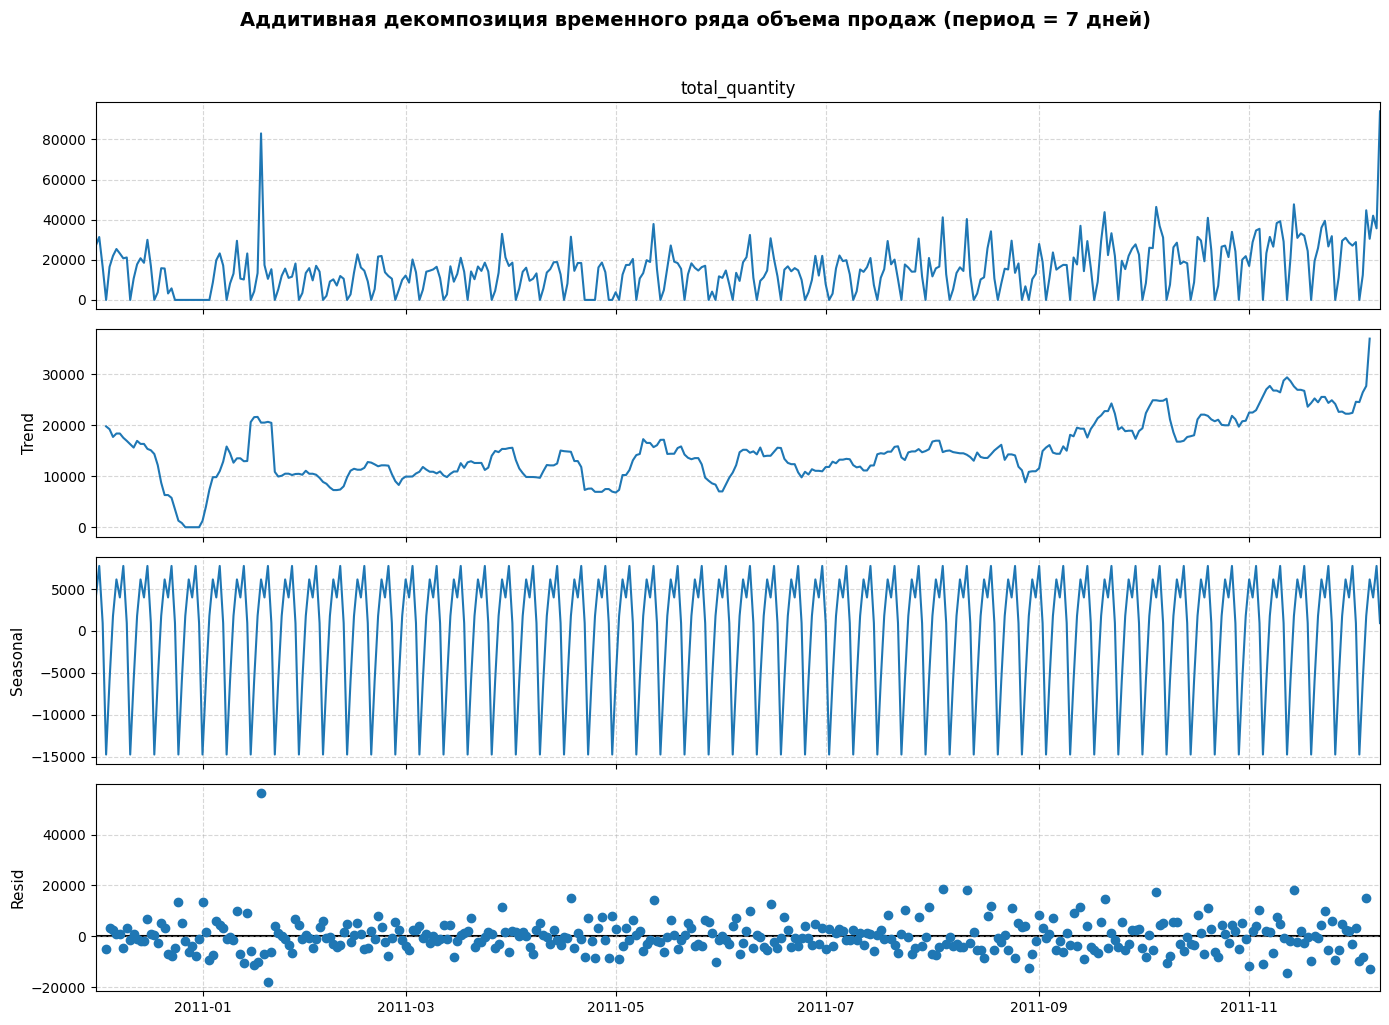

In [12]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Выполнение аддитивной декомпозиции для посуточного ряда розничных продаж с недельным периодом (period=7)
decomp = seasonal_decompose(total['total_quantity'], model='additive', period=7)

# Настройка размера и вывод графиков компонентов декомпозиции
fig = decomp.plot()
fig.set_size_inches(14, 10)
fig.suptitle('Аддитивная декомпозиция временного ряда объема продаж (период = 7 дней)', fontsize=14, fontweight='bold', y=1.02)

# Корректировка стиля графиков для академической подачи
for ax in fig.get_axes():
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.set_ylabel(ax.get_ylabel(), fontsize=11)

plt.tight_layout()
plt.show()

# 4.2 Построение сезонной модели SARIMA и сравнение качества прогнозов

Поскольку временной ряд ежедневных розничных продаж обладает выраженной недельной цикличностью, классическая модель ARIMA не способна полностью учесть эти колебания. Для моделирования такой структуры применяется расширение — модель $\text{SARIMA}(p,d,q)(P,D,Q)_s$

In [13]:
# Инициализация и обучение сезонной модели SARIMA
# Задаем период сезонности s=7 (недельная цикличность для посуточных данных)
p, d, q = 1, 1, 1
P, D, Q, s = 1, 1, 1, 7

model_sarima = SARIMAX(train['log_quantity'],
                       order=(p, d, q),
                       seasonal_order=(P, D, Q, s),
                       enforce_stationarity=False,
                       enforce_invertibility=False)

model_sarima_fit = model_sarima.fit(disp=False)

# Вывод краткого статистического отчета по обученной модели SARIMA
print(model_sarima_fit.summary())

# Генерация прогноза на тестовый интервал (horizon = 30 дней) в логарифмической шкале
forecast_sarima_log = model_sarima_fit.forecast(steps=horizon)

# Обратное преобразование точечного прогноза к исходной шкале (объем продаж)
forecast_sarima = np.expm1(forecast_sarima_log)

# Оценка качества сезонной модели на основе фактических тестовых данных
rmse_sarima = np.sqrt(mean_squared_error(test_actual, forecast_sarima))
mape_sarima = mean_absolute_percentage_error(test_actual, forecast_sarima)

# Вывод сравнительного анализа результатов
print("\n" + "="*50)
print(f'МЕТРИКИ КАЧЕСТВА НА ТЕСТОВОМ ИНТЕРВАЛЕ (исходная шкала):')
print(f'RMSE (ARIMA):  {rmse_arima:.2f}')
print(f'RMSE (SARIMA): {rmse_sarima:.2f}')
print(f'MAPE (ARIMA):  {mape_arima * 100:.2f}%')
print(f'MAPE (SARIMA): {mape_sarima * 100:.2f}%')
print("-"*50)

# Расчет относительного изменения метрик качества
rmse_improvement = (rmse_arima - rmse_sarima) / rmse_arima * 100
mape_improvement = (mape_arima - mape_sarima) / mape_arima * 100

print(f'Относительное улучшение RMSE: {rmse_improvement:.2f}%')
print(f'Относительное улучшение MAPE: {mape_improvement:.2f}%')
print("="*50)

                                     SARIMAX Results                                     
Dep. Variable:                      log_quantity   No. Observations:                  344
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 7)   Log Likelihood                -653.775
Date:                           Tue, 19 May 2026   AIC                           1317.550
Time:                                   18:53:28   BIC                           1336.500
Sample:                               12-01-2010   HQIC                          1325.111
                                    - 11-09-2011                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.1138      0.046     -2.471      0.013      -0.204      -0.024
ma.L1         -0.5622      0.038    -14.794

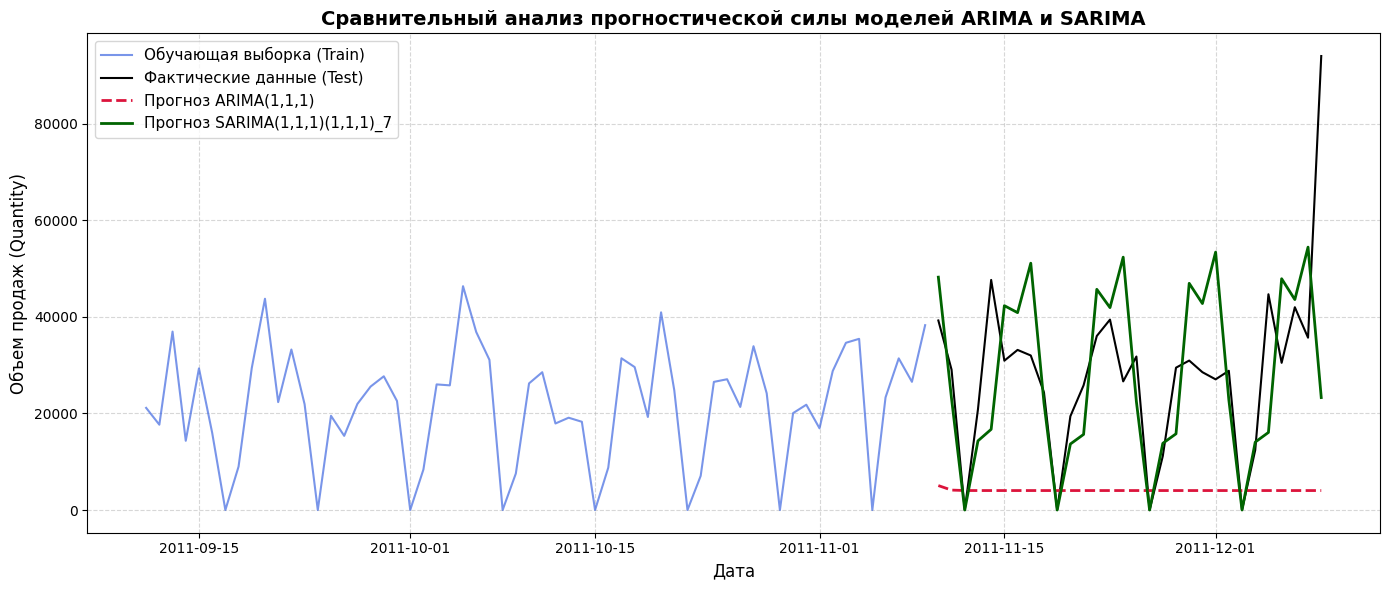

In [14]:
# Визуализация и сравнение результатов прогнозирования
plt.figure(figsize=(14, 6))

# Отображаем последние 60 дней обучающей выборки и весь тестовый интервал
plt.plot(train_actual.index[-60:], train_actual.iloc[-60:], label='Обучающая выборка (Train)', color='royalblue', alpha=0.7)
plt.plot(test_actual.index, test_actual, label='Фактические данные (Test)', color='black', linewidth=1.5)

# Траектории прогнозов моделей
plt.plot(test_actual.index, forecast_arima, label=f'Прогноз ARIMA({p},{d},{q})', color='crimson', linestyle='--', linewidth=2)
plt.plot(test_actual.index, forecast_sarima, label=f'Прогноз SARIMA({p},{d},{q})({P},{D},{Q})_{s}', color='darkgreen', linestyle='-', linewidth=2)

plt.title('Сравнительный анализ прогностической силы моделей ARIMA и SARIMA', fontsize=14, fontweight='bold')
plt.xlabel('Дата', fontsize=12)
plt.ylabel('Объем продаж (Quantity)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='upper left', fontsize=11)

plt.tight_layout()
plt.show()

# 5. Модель SARIMAX и учет внешних факторов (регрессоров)

В соответствии с Заданием 5 лабораторной работы, для повышения точности моделирования в структуру SARIMA добавляются внешние независимые переменные (экзогенные регрессоры). Модель принимает вид $\text{SARIMAX}(p,d,q)(P,D,Q)_s$.

Поскольку исходный код использовал специфические признаки энергетического сектора (потребление ветряной энергии и дамми-переменные месяцев), для нашего транзакционного датасета розничных продаж мы переработаем систему внешних факторов под экономическую логику ритейла:

Календарный признак «Выходные дни» (Is_Weekend): В субботу и воскресенье паттерны покупательской активности существенно отличаются от будней.

Календарный признак «День недели» (Day of Week): Вместо месячных дамми-переменных (актуальных для межгодовой динамики энергетики) мы создадим бинарные признаки для дней недели, так как наш ряд агрегирован по дням и имеет недельный шаг сезонности ($s=7$).

In [15]:
# 5.1 Генерация экзогенных регрессоров для ритейла

# 1. Признак выходного дня (1 — суббота/воскресенье, 0 — будни)
is_weekend = total.index.dayofweek.isin([5, 6]).astype(int)
is_weekend_series = pd.Series(is_weekend, index=total.index, name='is_weekend')

# 2. Дамми-переменные для дней недели (исключаем один день во избежание мультиколлинеарности)
day_dummies = pd.get_dummies(total.index.dayofweek, prefix='day', drop_first=True)
day_dummies = day_dummies.astype(int)
day_dummies.index = total.index

# Объединение всех внешних факторов в единую матрицу exog
exog = pd.concat([is_weekend_series, day_dummies], axis=1)

print("Типы данных и состав матрицы внешних факторов (exog):")
print(exog.dtypes.value_counts())
print(exog.head())

# 5.2 Разделение матрицы внешних факторов на train и test
exog_train = exog.loc[train.index]
exog_test = exog.loc[test.index]

# 5.3 Инициализация и обучение модели SARIMAX с внешними факторами
p, d, q = 1, 1, 1
P, D, Q, s = 1, 1, 1, 7

model_sarimax = SARIMAX(train['log_quantity'],
                        exog=exog_train,
                        order=(p, d, q),
                        seasonal_order=(P, D, Q, s),
                        enforce_stationarity=False,
                        enforce_invertibility=False)

model_sarimax_fit = model_sarimax.fit(disp=False)

# Вывод статистического отчета модели SARIMAX
print(model_sarimax_fit.summary())

# 5.4 Прогнозирование на тестовый интервал с передачей тестовых экзогенных факторов
forecast_sarimax_log = model_sarimax_fit.forecast(steps=horizon, exog=exog_test)

# Обратное преобразование точечного прогноза из логарифмической шкалы к объемам продаж
forecast_sarimax = np.expm1(forecast_sarimax_log)

# 5.5 Оценка качества модели на основе фактических тестовых данных
rmse_sarimax = np.sqrt(mean_squared_error(test_actual, forecast_sarimax))
mape_sarimax = mean_absolute_percentage_error(test_actual, forecast_sarimax)

print("\n" + "="*50)
print(f'МЕТРИКИ КАЧЕСТВА МОДЕЛИ SARIMAX НА ТЕСТОВОМ ИНТЕРВАЛЕ:')
print(f'RMSE (SARIMAX): {rmse_sarimax:.2f}')
print(f'MAPE (SARIMAX): {mape_sarimax * 100:.2f}%')
print("="*50)

Типы данных и состав матрицы внешних факторов (exog):
int64    7
Name: count, dtype: int64
            is_weekend  day_1  day_2  day_3  day_4  day_5  day_6
date                                                            
2010-12-01           0      0      1      0      0      0      0
2010-12-02           0      0      0      1      0      0      0
2010-12-03           0      0      0      0      1      0      0
2010-12-04           1      0      0      0      0      1      0
2010-12-05           1      0      0      0      0      0      1
                                     SARIMAX Results                                     
Dep. Variable:                      log_quantity   No. Observations:                  344
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 7)   Log Likelihood                -653.775
Date:                           Tue, 19 May 2026   AIC                           1331.550
Time:                                   18:55:42   BIC                           1377.030
Samp

Сводная таблица точности моделей:
 Модель         RMSE     MAPE (%)
  ARIMA 30104.481369 2.422539e+20
 SARIMA 18722.875617 1.092818e+17
SARIMAX 18722.875441 1.092818e+17


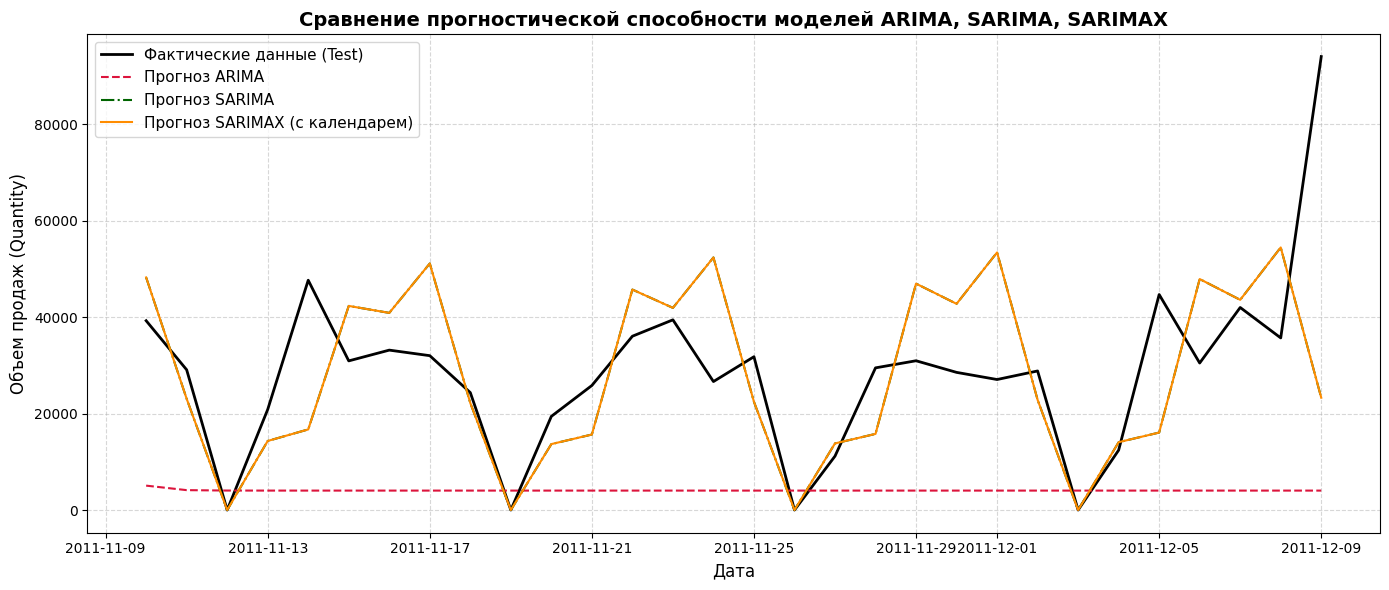

In [18]:
# Вывод сводной таблицы метрик эффективности в консоль
models_summary = pd.DataFrame({
    'Модель': ['ARIMA', 'SARIMA', 'SARIMAX'],
    'RMSE': [rmse_arima, rmse_sarima, rmse_sarimax],
    'MAPE (%)': [mape_arima * 100, mape_sarima * 100, mape_sarimax * 100]
})
print("Сводная таблица точности моделей:")
print(models_summary.to_string(index=False))

# Визуализация всех построенных прогнозов для сравнения
plt.figure(figsize=(14, 6))

plt.plot(test_actual.index, test_actual, label='Фактические данные (Test)', color='black', linewidth=2)
plt.plot(test_actual.index, forecast_arima, label='Прогноз ARIMA', color='crimson', linestyle='--')
plt.plot(test_actual.index, forecast_sarima, label='Прогноз SARIMA', color='darkgreen', linestyle='-.')
plt.plot(test_actual.index, forecast_sarimax, label='Прогноз SARIMAX (с календарем)', color='darkorange', linestyle='-')

plt.title('Сравнение прогностической способности моделей ARIMA, SARIMA, SARIMAX', fontsize=14, fontweight='bold')
plt.xlabel('Дата', fontsize=12)
plt.ylabel('Объем продаж (Quantity)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='upper left', fontsize=11)

plt.tight_layout()
plt.show()

# 6. Автоматизация подбора параметров (pmdarima)

В соответствии с Заданием 6 лабораторной работы, ручной подбор параметров на основе визуального анализа коррелограмм ACF/PACF полезен для понимания структуры ряда, однако на практике часто применяется автоматизированный алгоритм. Библиотека pmdarima предоставляет функцию auto_arima, которая реализует пошаговый поиск (stepwise) наилучшего набора гиперпараметров модели на основе минимизации информационного критерия Акаике ($\text{AIC}$).

Для адаптации автоматического подбора под наши транзакционные данные розничной торговли необходимо скорректировать два ключевых параметра:

Период сезонности (m): Изменяем значение m=12 (месячная сезонность исходного ряда энергетики) на m=7 (недельная сезонность ежедневного ряда продаж).

Переменная: Поиск оптимальной конфигурации запускается на логарифмированном обучающем ряду train['log_quantity'] для сохранения стабильной дисперсии, а финальные метрики оцениваются на тестовой выборке после потенцирования прогноза с помощью np.expm1.

In [16]:
# 6.1 Автоматический подбор оптимальных параметров модели с помощью pmdarima
# Задаем период сезонности m=7 для посуточных данных
auto_model = pm.auto_arima(train['log_quantity'],
                          seasonal=True, m=7,
                          start_p=0, max_p=3,
                          start_q=0, max_q=3,
                          start_P=0, max_P=2,
                          start_Q=0, max_Q=2,
                          trace=True,
                          error_action='ignore',
                          suppress_warnings=True,
                          stepwise=True)

# Вывод полного статистического отчета для модели, выбранной алгоритмом автоматически
print(auto_model.summary())

# 6.2 Генерация прогноза автоматической моделью на тестовый интервал (horizon = 30 дней)
forecast_auto_log = auto_model.predict(n_periods=horizon)

# Обратное преобразование точечного прогноза к исходной шкале объемов продаж
forecast_auto = np.expm1(forecast_auto_log)

# 6.3 Расчет метрик качества для автоматически подобранной модели
rmse_auto = np.sqrt(mean_squared_error(test_actual, forecast_auto))
mape_auto = mean_absolute_percentage_error(test_actual, forecast_auto)

print("\n" + "="*50)
print(f'МЕТРИКИ КАЧЕСТВА МОДЕЛИ AUTO_ARIMA НА ТЕСТОВОМ ИНТЕРВАЛЕ:')
print(f'Оптимальная структура модели: {auto_model.order} x {auto_model.seasonal_order}')
print(f'RMSE (auto_arima): {rmse_auto:.2f}')
print(f'MAPE (auto_arima): {mape_auto * 100:.2f}%')
print("="*50)

Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[7] intercept   : AIC=2091.092, Time=0.08 sec
 ARIMA(1,1,0)(1,0,0)[7] intercept   : AIC=1550.650, Time=1.34 sec
 ARIMA(0,1,1)(0,0,1)[7] intercept   : AIC=inf, Time=3.12 sec
 ARIMA(0,1,0)(0,0,0)[7]             : AIC=2089.092, Time=0.08 sec
 ARIMA(1,1,0)(0,0,0)[7] intercept   : AIC=2019.505, Time=0.08 sec
 ARIMA(1,1,0)(2,0,0)[7] intercept   : AIC=1525.166, Time=3.27 sec
 ARIMA(1,1,0)(2,0,1)[7] intercept   : AIC=inf, Time=9.12 sec
 ARIMA(1,1,0)(1,0,1)[7] intercept   : AIC=inf, Time=2.99 sec
 ARIMA(0,1,0)(2,0,0)[7] intercept   : AIC=1602.539, Time=1.63 sec
 ARIMA(2,1,0)(2,0,0)[7] intercept   : AIC=inf, Time=1.32 sec
 ARIMA(1,1,1)(2,0,0)[7] intercept   : AIC=1491.118, Time=0.62 sec
 ARIMA(1,1,1)(1,0,0)[7] intercept   : AIC=1521.438, Time=0.43 sec
 ARIMA(1,1,1)(2,0,1)[7] intercept   : AIC=inf, Time=1.88 sec
 ARIMA(1,1,1)(1,0,1)[7] intercept   : AIC=inf, Time=1.47 sec
 ARIMA(0,1,1)(2,0,0)[7] intercept   : AIC=1490.319, Time=0.57 s

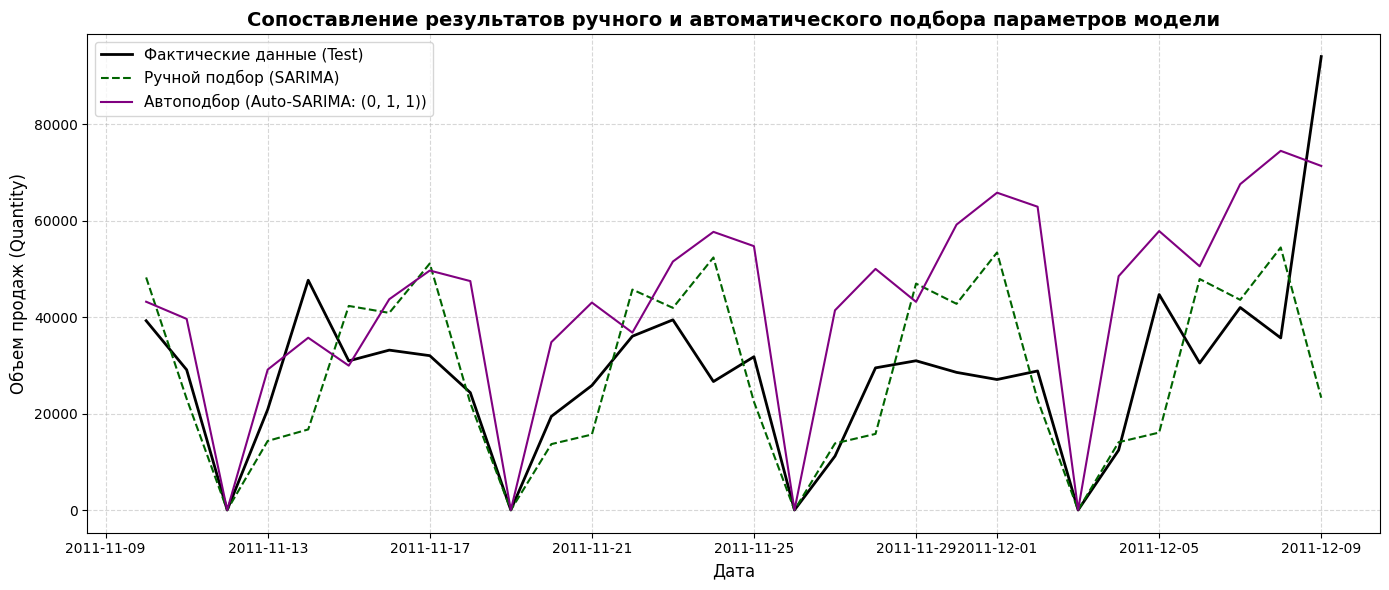

In [17]:
# Визуализация результатов ручного и автоматического подбора параметров
plt.figure(figsize=(14, 6))

plt.plot(test_actual.index, test_actual, label='Фактические данные (Test)', color='black', linewidth=2)
plt.plot(test_actual.index, forecast_sarima, label='Ручной подбор (SARIMA)', color='darkgreen', linestyle='--')
plt.plot(test_actual.index, forecast_auto, label=f'Автоподбор (Auto-SARIMA: {auto_model.order})', color='purple', linestyle='-')

plt.title('Сопоставление результатов ручного и автоматического подбора параметров модели', fontsize=14, fontweight='bold')
plt.xlabel('Дата', fontsize=12)
plt.ylabel('Объем продаж (Quantity)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='upper left', fontsize=11)

plt.tight_layout()
plt.show()